# Блок 1. Задача 2: классификационное дерево и Random Forest

Цель: по химическим характеристикам вина определить сорт.

Используется датасет `Wine` из `scikit-learn`. В одной задаче сравниваются две модели: `DecisionTreeClassifier` и `RandomForestClassifier`.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme(style="whitegrid")


## Загрузка и анализ данных


In [9]:
wine = load_wine(as_frame=True)
df_wine = wine.frame.copy()
df_wine["target_name"] = df_wine["target"].map(dict(enumerate(wine.target_names)))

display(df_wine.head())
print("Размер датасета:", df_wine.shape)
print("Распределение классов:")
print(df_wine["target_name"].value_counts())


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


Размер датасета: (178, 15)
Распределение классов:
target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


## Подготовка данных


In [10]:
X = df_wine.drop(columns=["target", "target_name"])
y = df_wine["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Обучение моделей


In [11]:
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4,
    min_samples_leaf=2,
)
tree_model.fit(X_train_scaled, y_train)

forest_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
)
forest_model.fit(X_train_scaled, y_train)


RandomForestClassifier(random_state=42)

## Метрики


In [12]:
models = {
    "Decision Tree": tree_model,
    "Random Forest": forest_model,
}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"{name}")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
    print(classification_report(y_test, y_pred, target_names=wine.target_names))
    print("-" * 60)


Decision Tree
Accuracy: 1.0
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

------------------------------------------------------------
Random Forest
Accuracy: 1.0
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

------------------------------------------------------------


## Матрицы ошибок


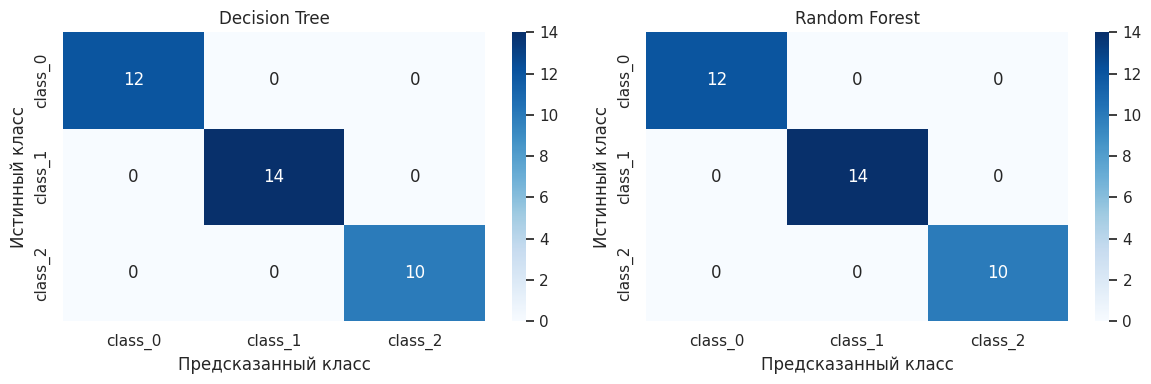

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=wine.target_names,
        yticklabels=wine.target_names,
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Предсказанный класс")
    ax.set_ylabel("Истинный класс")

plt.tight_layout()


## Визуализация дерева решений


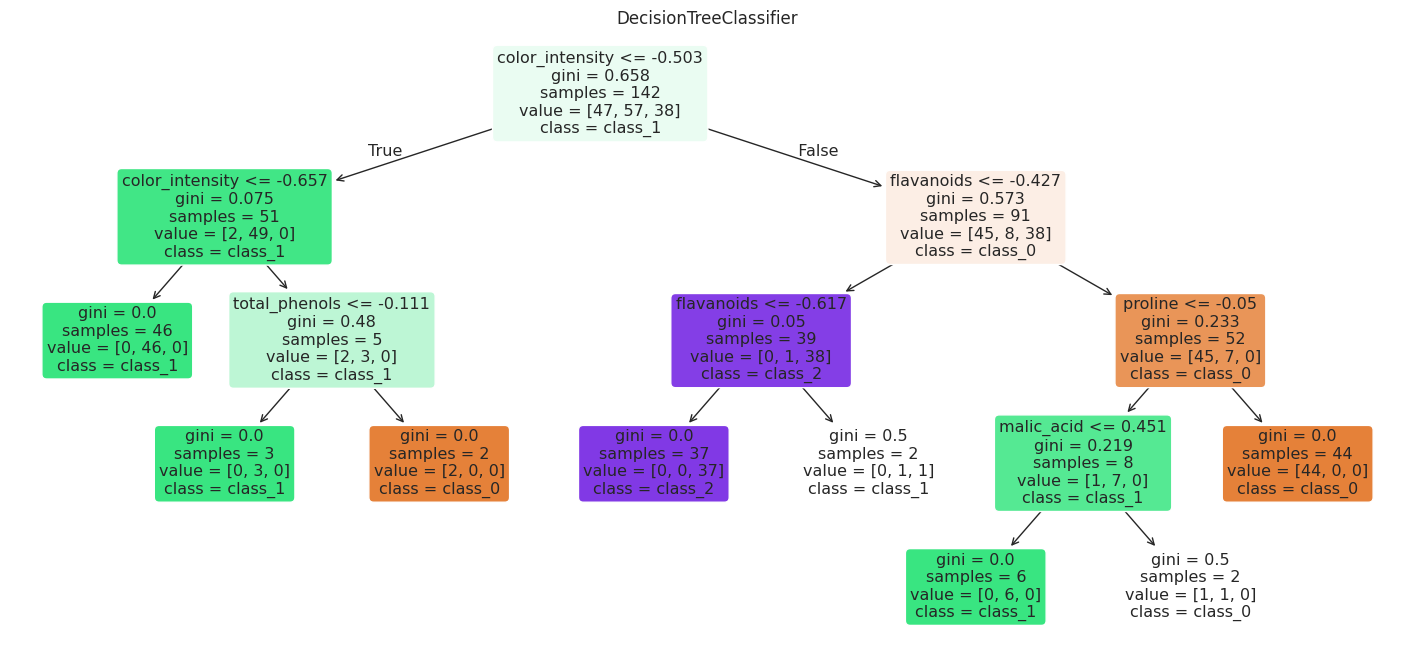

In [14]:
plt.figure(figsize=(18, 8))
plot_tree(
    tree_model,
    feature_names=wine.feature_names,
    class_names=list(wine.target_names),
    filled=True,
    rounded=True,
)
plt.title("DecisionTreeClassifier")
plt.show()


## Вывод

Входные данные соответствуют задаче классификации: используется датасет `Wine` размером `178 x 15`, в `X` входят `13` числовых химических признаков вина, а целевая переменная `y = target` содержит три класса сортов: `class_0`, `class_1` и `class_2`. После стратифицированного разбиения в тестовой выборке оказалось `36` объектов: `12`, `14` и `10` объектов по классам.

По текущему запуску `DecisionTreeClassifier` получил `Accuracy = 1.0`, а `RandomForestClassifier` также получил `Accuracy = 1.0`. В отчёте классификации у обеих моделей `precision`, `recall` и `f1-score` равны `1.00` для всех трёх классов, значит на данном train/test-разбиении обе модели классифицировали тестовую выборку без ошибок.

Классификационное дерево дополнительно даёт интерпретируемые правила разбиения, которые можно посмотреть на визуализации дерева. `Random Forest` использует ансамбль деревьев и обычно устойчивее к переобучению, но в этом конкретном запуске по метрикам преимущества над одиночным деревом не показал, потому что обе модели достигли одинакового максимального качества на тестовой выборке.
